# Домашнее задание 5
## Полушина Дарья Б06-303
## Отчет

### Часть 1 — Анализ FastQC

С помощью SRA Explorer скачаем 4 любых ERRxxxxxx файла до 1000 Mb из PRJEB84057.

```
#!/usr/bin/env bash
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/003/ERR14230603/ERR14230603.fastq.gz -o ERR14230603_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/007/ERR14230607/ERR14230607.fastq.gz -o ERR14230607_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/002/ERR14230602/ERR14230602.fastq.gz -o ERR14230602_Illumina_HiSeq_4000_sequencing.fastq.gz
curl -L ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR142/000/ERR14230600/ERR14230600.fastq.gz -o ERR14230600_Illumina_HiSeq_4000_sequencing.fastq.gz
```

Далее скрипт, который запускает `fastqc` на этих скачанных данных и агрегирует все отчеты в один с помощью `multiqc`.
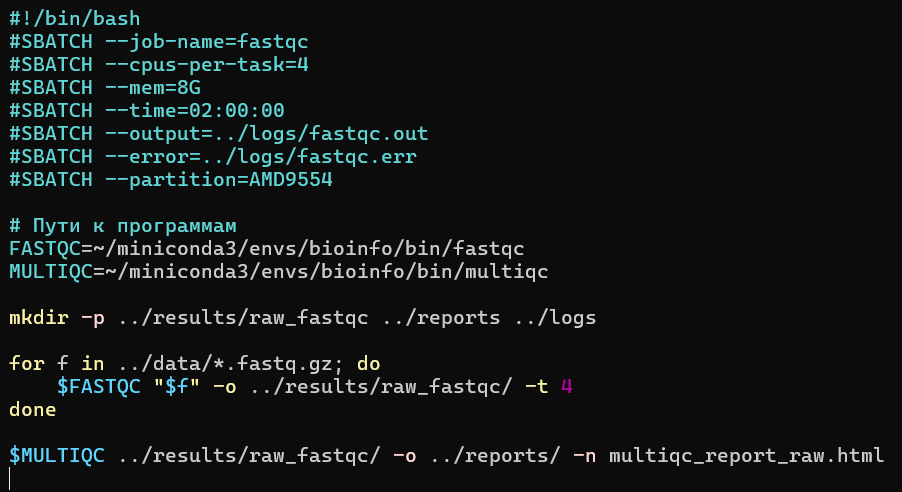

### Часть 2 — Тримминг

Используя отчеты MultiQC из первой части, определите:
- Есть ли в ваших данных адаптеры?
- Есть ли участки с плохим качеством (Q<20) в конце ридов?

Я использую получившийся отчет `multiqc_report_raw.html` и результаты FastQC.
1) Адаптеров в моих данных нет:
    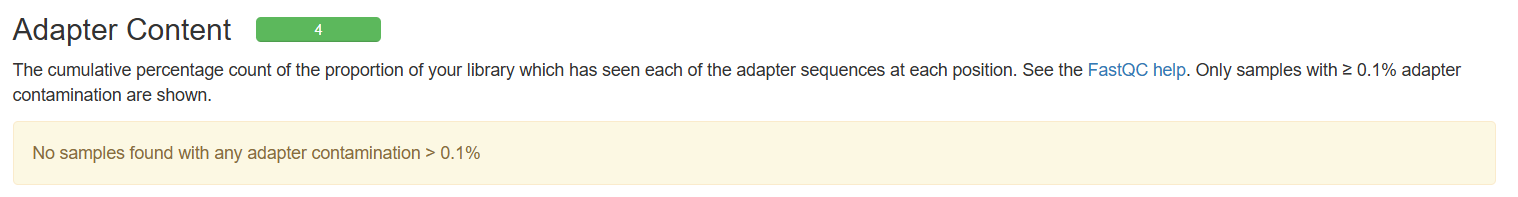
2) Участков с плохим качеством (Q<20) в конце ридов также нет
   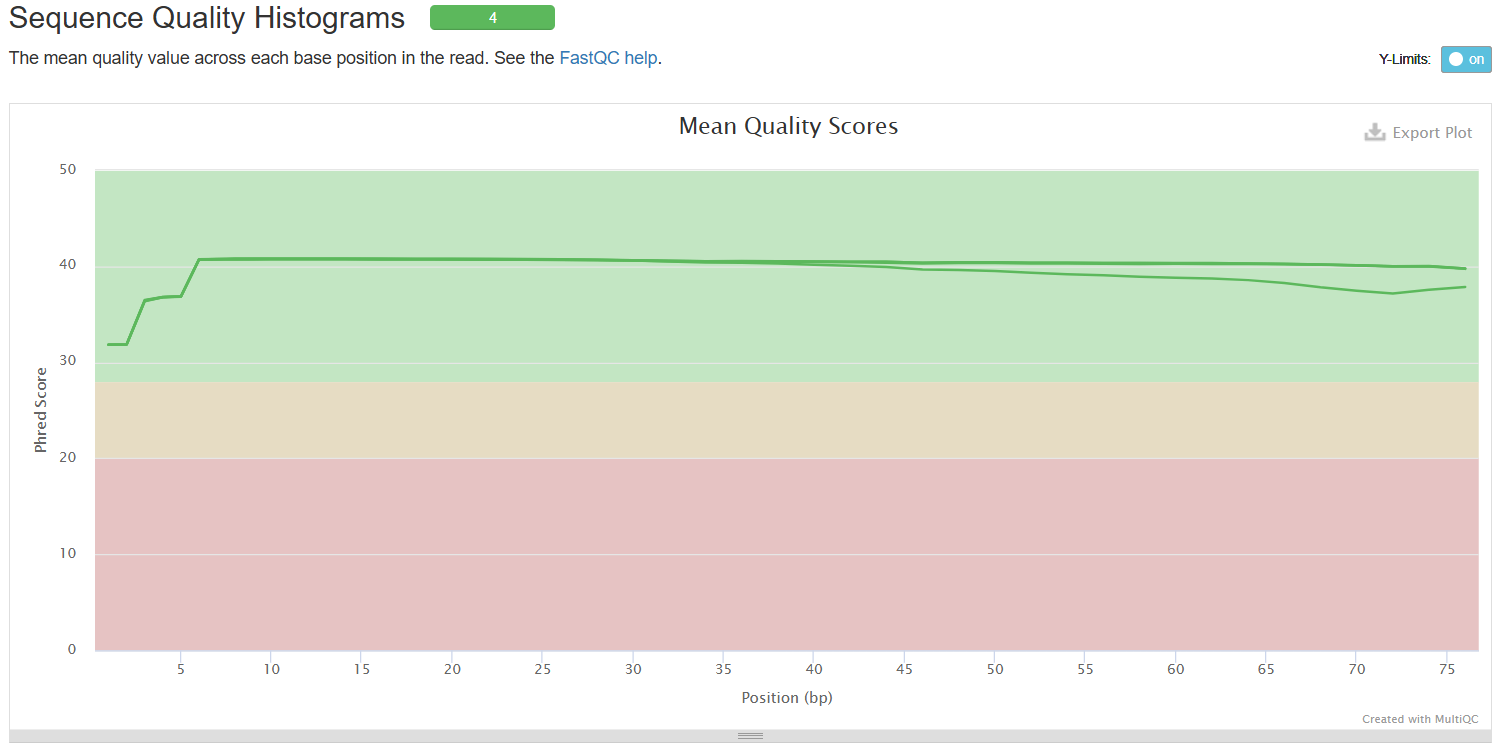
   Если смотреть отдельно результат FastQC по каждому образцу, то таких ридов действительно нет.

Теперь SLURM скрипт для запуска fastp (или Trimmomatic) который:
- Обрежет адаптеры (auto-detection).
- Применит скользящее окно (5:20) для удаления плохих участков.
- Отбросит риды короче 36 п.н.
- Сохранит очищенные файлы (например, *_trimmed.fastq.gz).
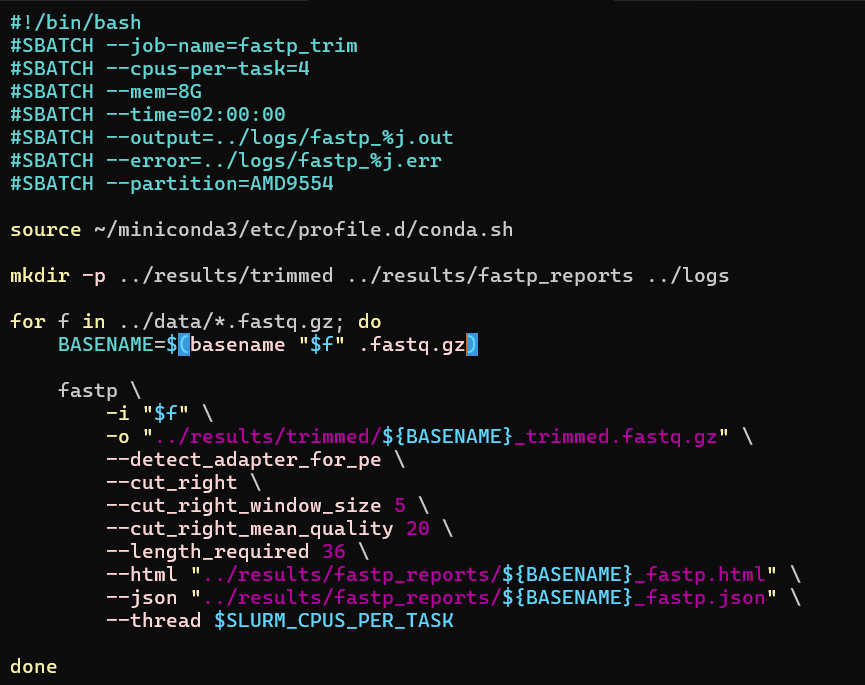

Результаты здесь:
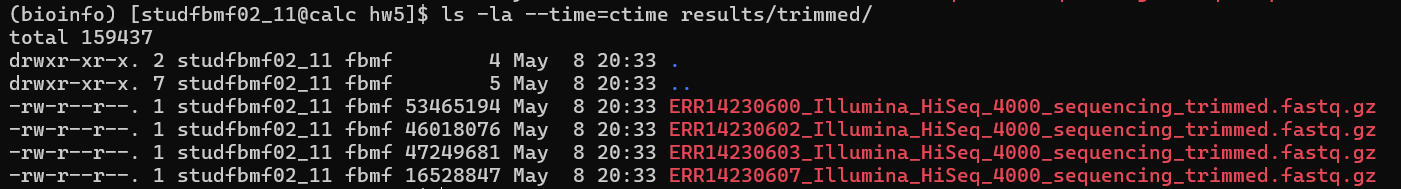

### Часть 3 — Контроль качества после тримминга

Запускаем FastQC повторно на *_trimmed.fastq.gz и снова собераем отчет MultiQC.

`run_fastqc_trimmed.slurm`
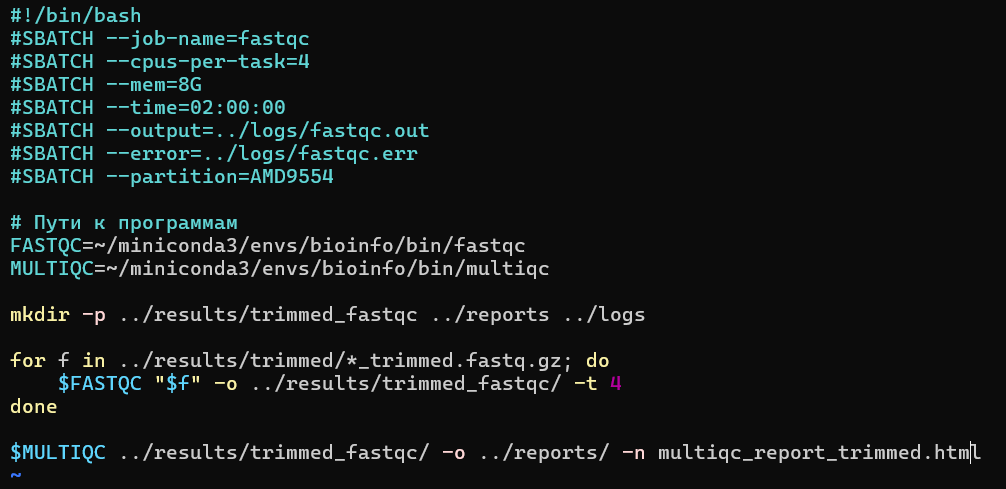

Результаты:
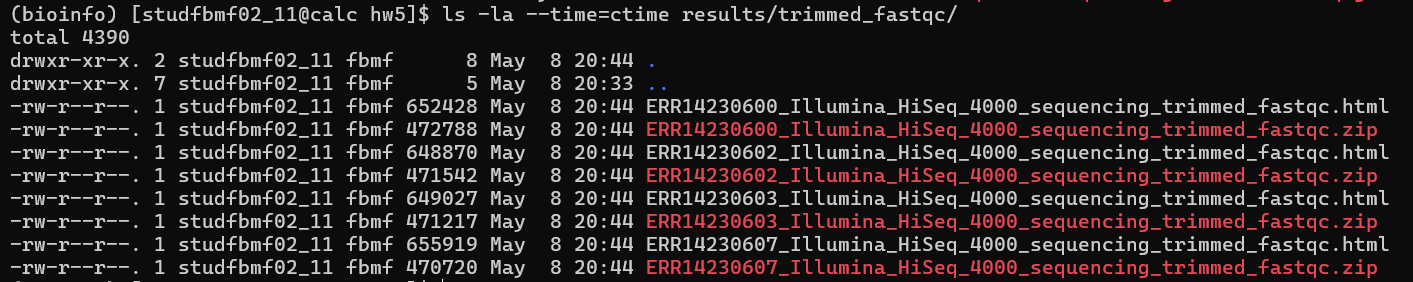

### Результаты

Так как и после первой части результаты были хорошие (не было адаптеров, не было участков с плохим качеством (Q<20) в конце ридов), то и после остальной работы они положительные. Но некоторые изменения после тримминга произошли, а именно:
- риды короче 36 п.н. были отброшены для всех образцов, уменьшилось суммарное число нуклеотидов
- ERR14230600: улучшение Per sequence GC content. Реальное распределение среднего GC-состава (%) по всем ридам в файле приблизилось к теоретическому.
  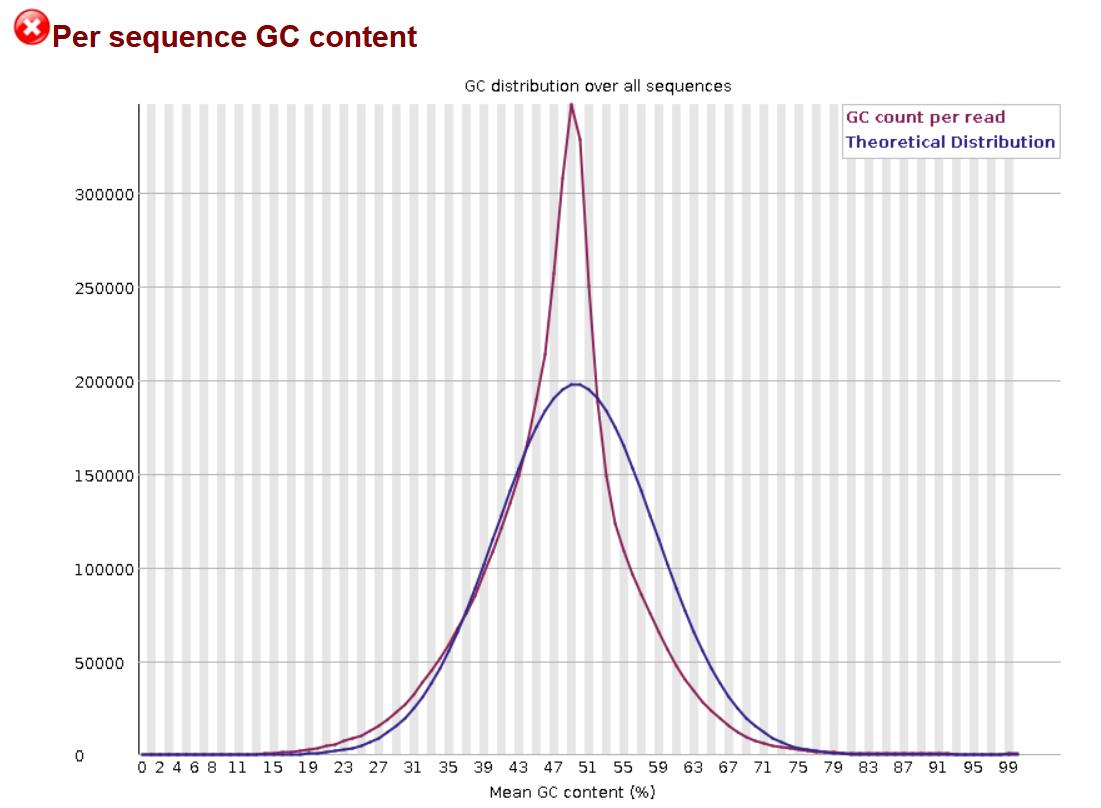
  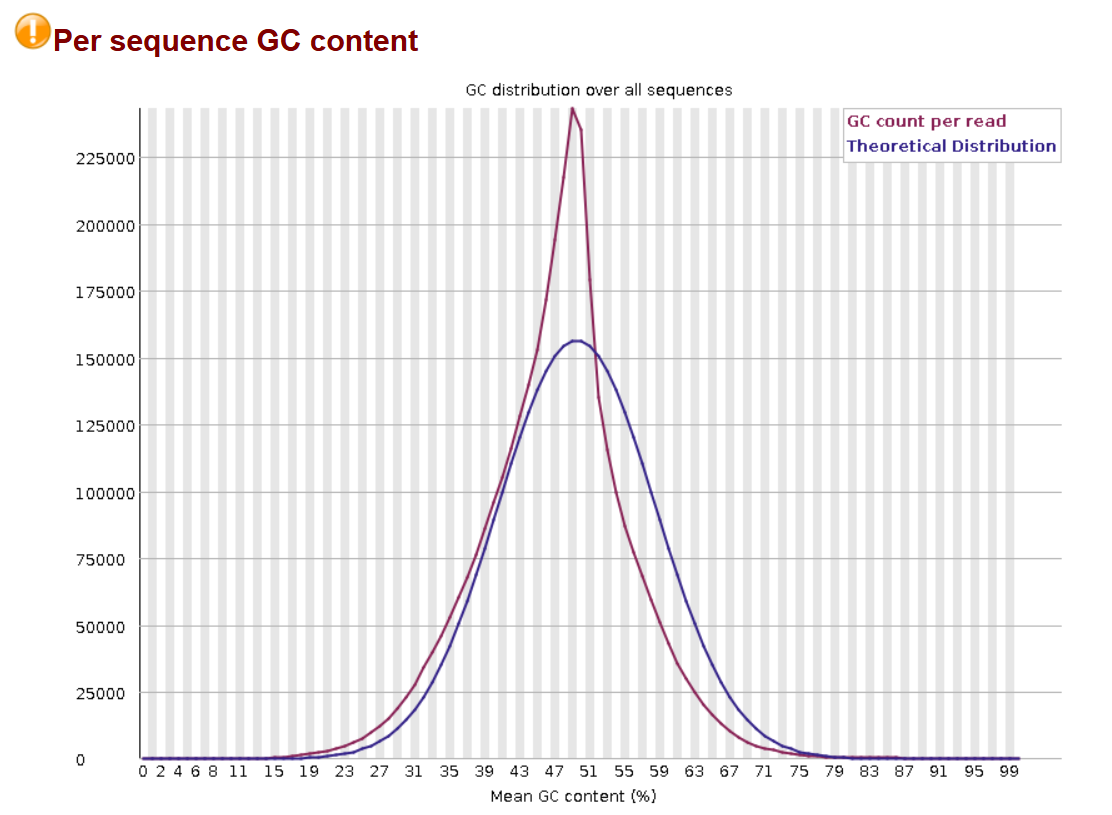
- улучшилось качество в хвосте у ERR14230607
  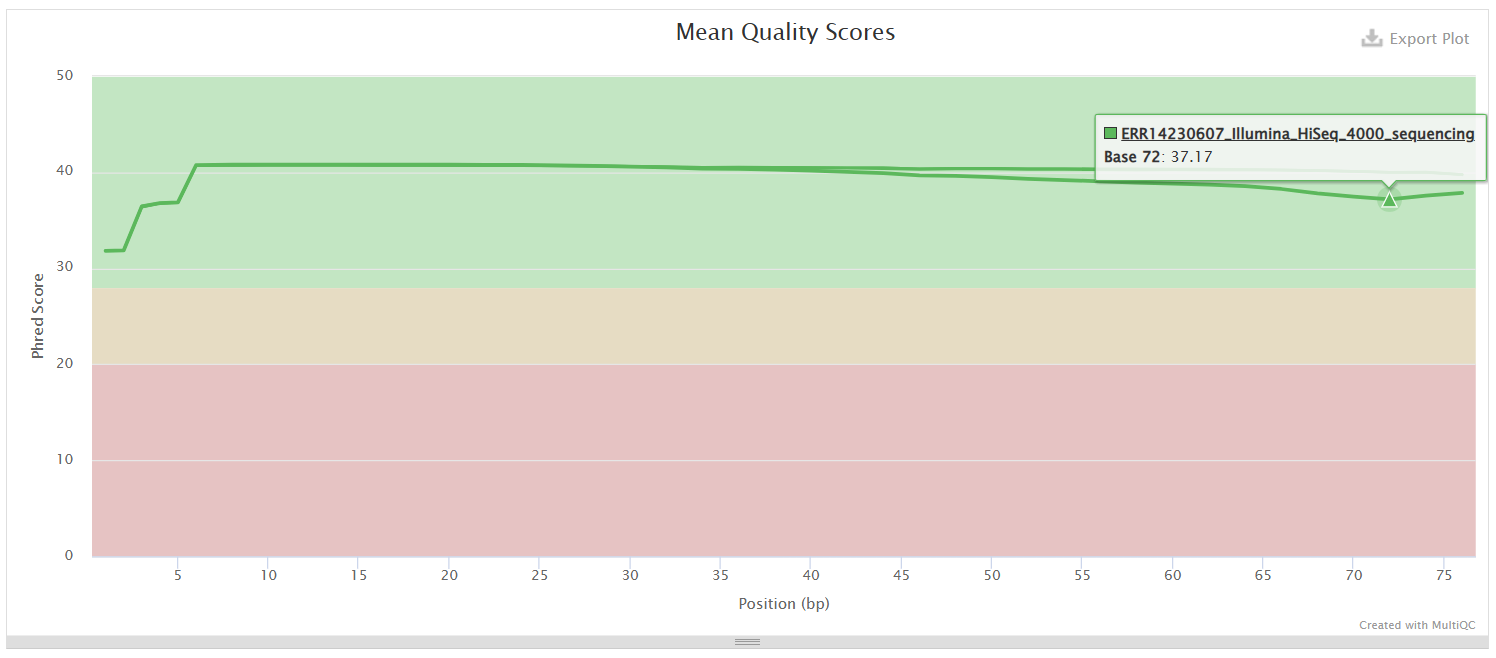
  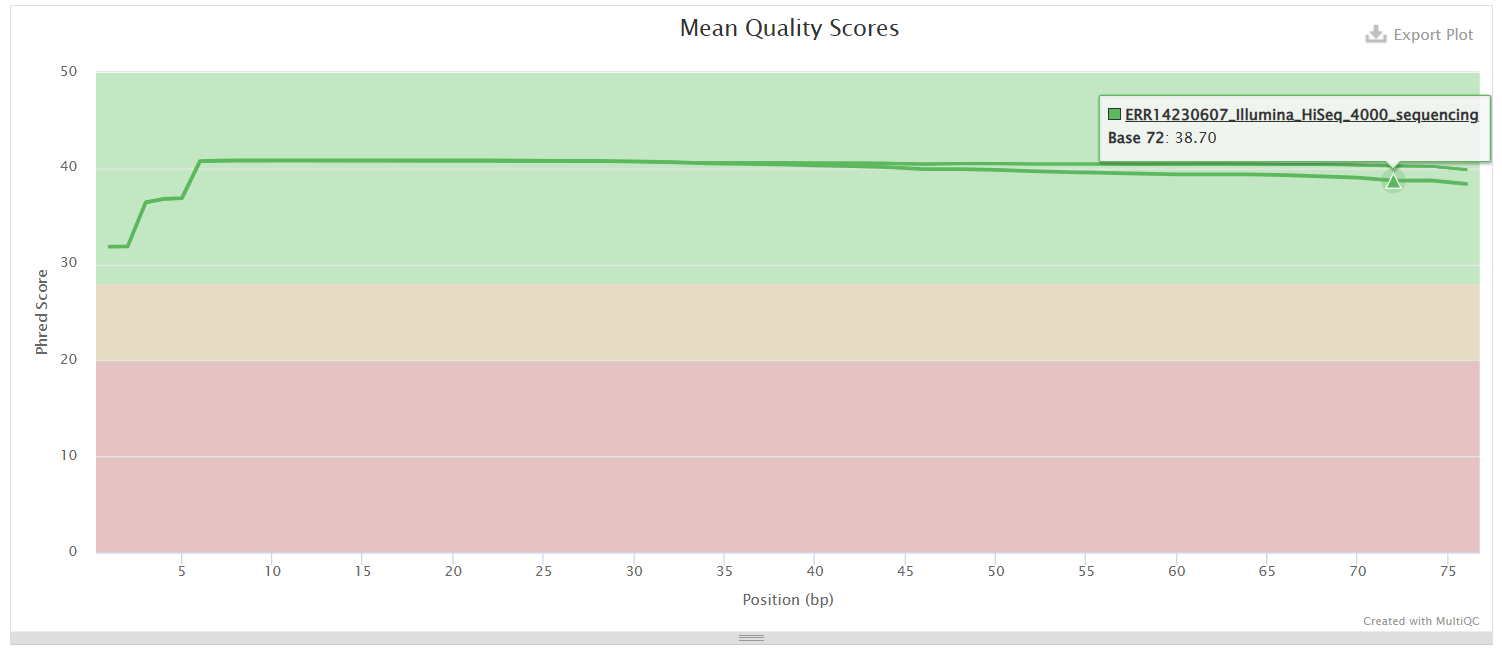
  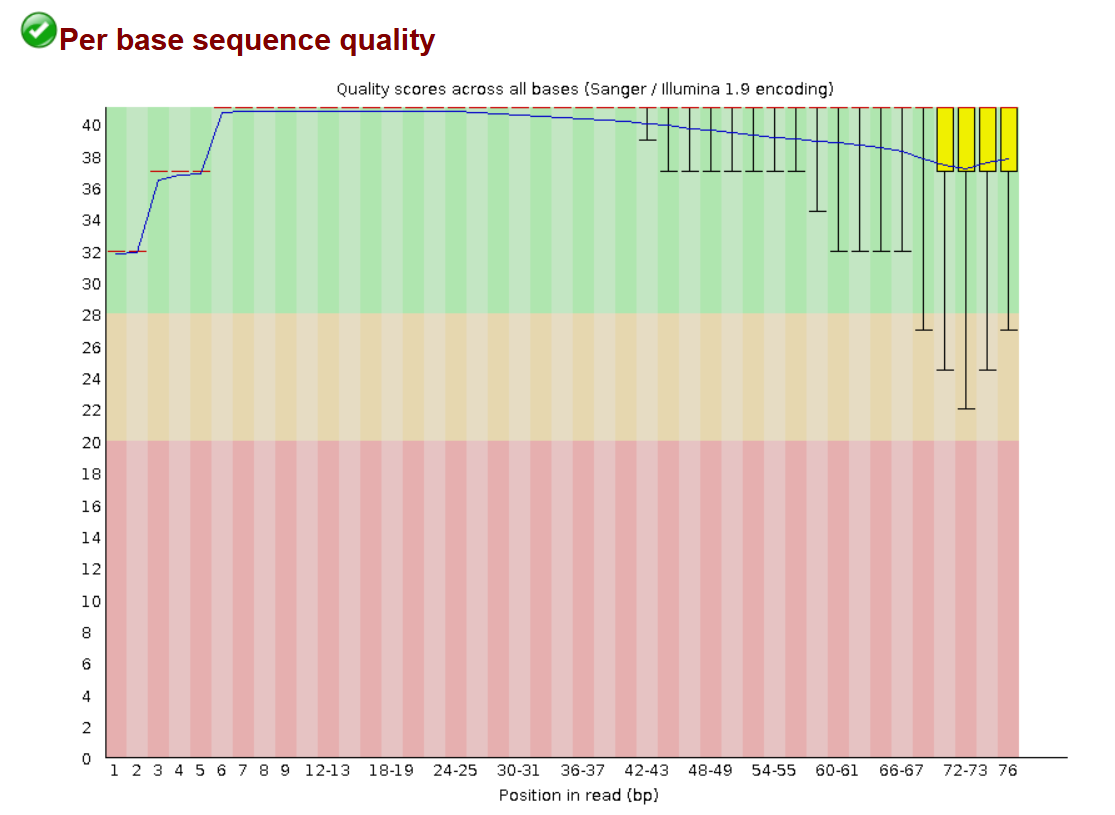
  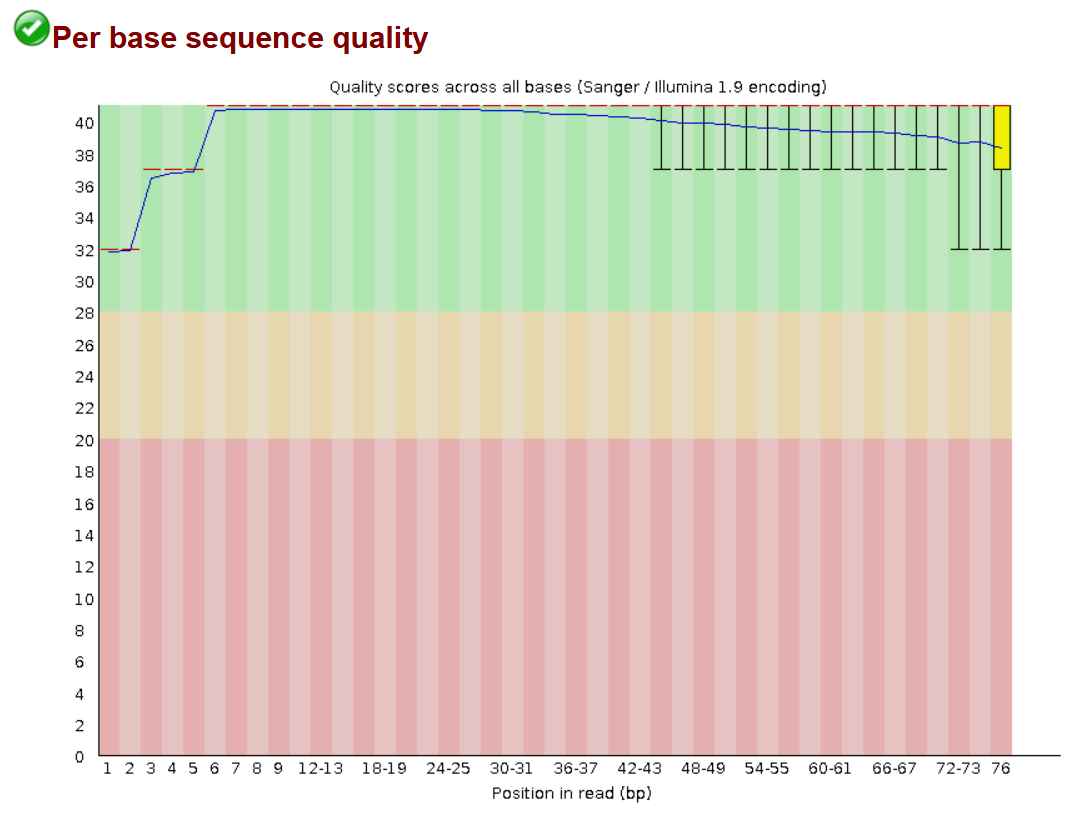

### Выводы

В ходе выполнения задания были выполнены анализ FastQC, тримминг и контроль качества после тримминга. Особых изменений в результатах замечено не было, так как в выбранных данных и на первой стадии были хорошие результаты по наличию адаптеров и качеству ридов. Другие же параметры не улучшились, так как это не задача тримминга.